In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

In [14]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [16]:
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

In [17]:
for col in df.columns:
    if df[col].nunique() <= 5:
        print(f"{col:18s} {sorted(df[col].unique().tolist())}")

gender             ['Female', 'Male']
SeniorCitizen      [0, 1]
Partner            ['No', 'Yes']
Dependents         ['No', 'Yes']
PhoneService       ['No', 'Yes']
MultipleLines      ['No', 'No phone service', 'Yes']
InternetService    ['DSL', 'Fiber optic', 'No']
OnlineSecurity     ['No', 'No internet service', 'Yes']
OnlineBackup       ['No', 'No internet service', 'Yes']
DeviceProtection   ['No', 'No internet service', 'Yes']
TechSupport        ['No', 'No internet service', 'Yes']
StreamingTV        ['No', 'No internet service', 'Yes']
StreamingMovies    ['No', 'No internet service', 'Yes']
Contract           ['Month-to-month', 'One year', 'Two year']
PaperlessBilling   ['No', 'Yes']
PaymentMethod      ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
Churn              ['No', 'Yes']


## Missing values

In [18]:
df.isna().sum().sum()

np.int64(0)

In [20]:
blank = df["TotalCharges"].str.strip() == ""
print("Blank TotalCharges:", blank.sum())
df.loc[blank, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [22]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)
df["TotalCharges"].dtype, df["TotalCharges"].isna().sum()

(dtype('float64'), np.int64(0))

In [23]:
print("Duplicate rows:", df.drop(columns="customerID").duplicated().sum())

Duplicate rows: 22


## Target: churn rate

,count,percent
Churn,,
No,5174,73.5
Yes,1869,26.5


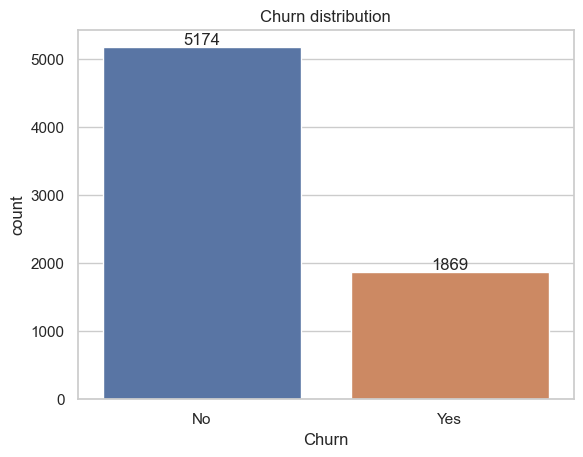

In [27]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True).mul(100).round(1)
display(pd.DataFrame({"count": churn_counts, "percent": churn_pct}))

ax = sns.countplot(data=df, x="Churn", hue="Churn", palette=["#4C72B0", "#DD8452"])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
ax.set_title("Churn distribution")
plt.show()

## Numeric features

In [28]:
NUM = ["tenure", "MonthlyCharges", "TotalCharges"]
df[NUM].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


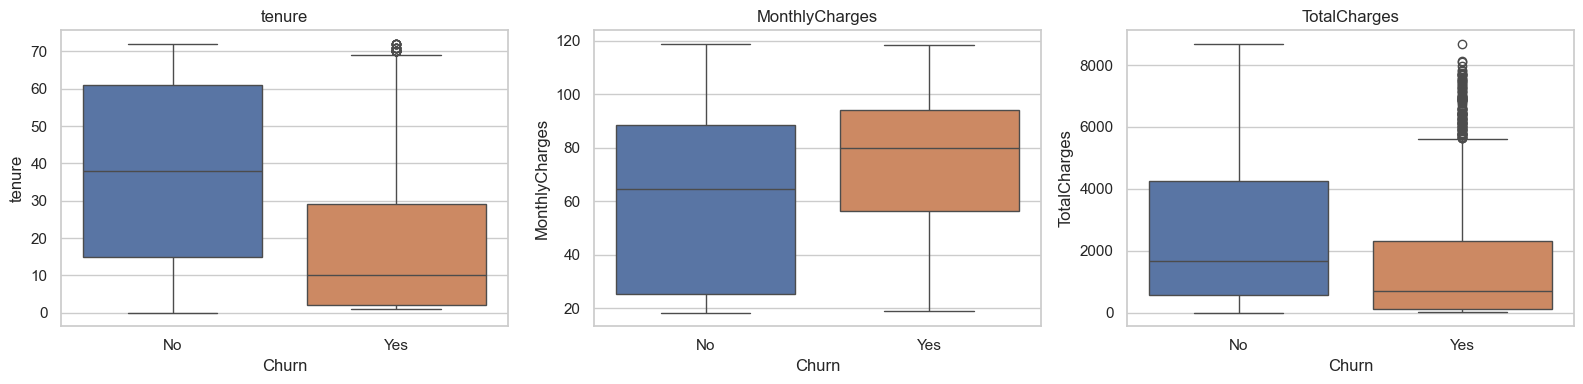

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, NUM):
    sns.boxplot(data=df, x="Churn", y=col, hue="Churn", ax=ax, legend=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Categorical features

In [33]:
CAT = [c for c in df.columns if c not in NUM + ["customerID", "Churn"]]
print(len(CAT), CAT)

16 ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [34]:
def churn_rate(col):
    return df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100).round(1)

spread = {c: churn_rate(c).max() - churn_rate(c).min() for c in CAT}
spread = pd.Series(spread).sort_values(ascending=False)
spread.rename("churn-rate spread (pp)").to_frame()

,churn-rate spread (pp)
Contract,39.9
InternetService,34.5
OnlineSecurity,34.4
TechSupport,34.2
OnlineBackup,32.5
DeviceProtection,31.7
PaymentMethod,30.1
StreamingMovies,26.3
StreamingTV,26.1
SeniorCitizen,18.1


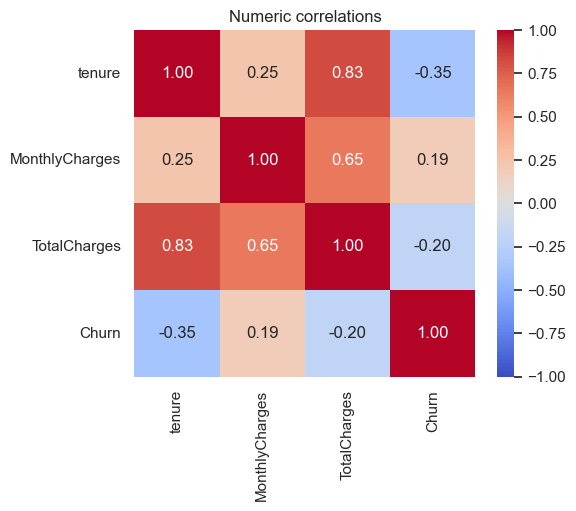

In [35]:
corr_df = df[NUM].assign(Churn=df["Churn"].eq("Yes").astype(int))
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Numeric correlations")
plt.show()

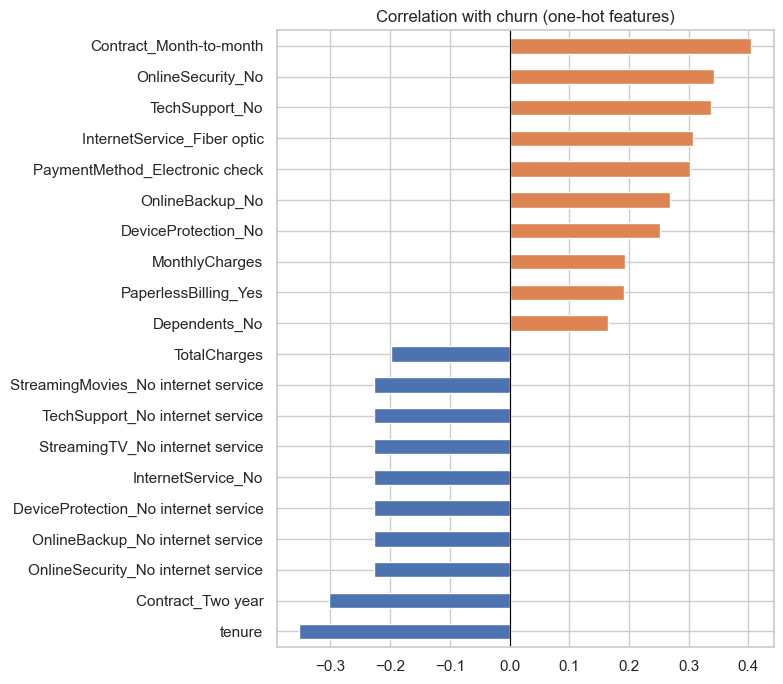

In [36]:
encoded = pd.get_dummies(df.drop(columns=["customerID", "Churn"]), columns=CAT, dtype=int)
target = df["Churn"].eq("Yes").astype(int)
corr_with_churn = encoded.corrwith(target).sort_values()

plt.figure(figsize=(8, 7))
top = pd.concat([corr_with_churn.head(10), corr_with_churn.tail(10)])
top.plot.barh(color=np.where(top > 0, "#DD8452", "#4C72B0"))
plt.title("Correlation with churn (one-hot features)")
plt.axvline(0, c="black", lw=0.8)
plt.tight_layout()
plt.show()

In [38]:
TARGET = "Churn"
DROP_COLS = ["customerID"]

NUMERIC_COLS = ["tenure", "MonthlyCharges", "TotalCharges"]

CATEGORICAL_COLS = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]


print(f"{len(NUMERIC_COLS)} numeric + {len(CATEGORICAL_COLS)} categorical = "
      f"{len(NUMERIC_COLS) + len(CATEGORICAL_COLS)} features")

3 numeric + 16 categorical = 19 features
